In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.get_data import load_data, get_cell_slice, get_trial_slice
from src.clustering_tools import run_clustering

In [3]:
# Simulated data
# X has shape (4 cvovariates, 15000 x 4 subjects = 60000 time bins)
# Y has shape (60000, 1) - one spike count per time bin
# cell_ids uniquely identify each cell across all subjects
# rec_ids uniquely identify each recording
# filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
# X, Y, cell_ids, rec_ids = load_data("..resources/data/simulated", filenames)


# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

In [5]:
X

array([[0.05788204, 0.0124372 , 0.02870367, ..., 0.02792639, 0.09636134,
        0.04126259],
       [0.00972409, 0.03447027, 0.03174838, ..., 0.11904028, 0.04367798,
        0.18611472],
       [0.04518889, 0.00592502, 0.02674753, ..., 0.05683636, 0.02079811,
        0.03129891],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [6]:
Y

array([1., 1., 0., ..., 0., 0., 0.])

In [7]:
np.unique(Y[Y < 0])

array([], dtype=float64)

In [8]:
np.isnan(Y).any()

False

In [9]:
print("Max Y:", np.max(Y))
print("Any inf in Y:", np.isinf(Y).any())

Max Y: 21.0
Any inf in Y: False


In [10]:
cell_ids

array([  1,   1,   1, ..., 247, 247, 247], dtype=uint8)

In [11]:
np.unique(cell_ids)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [12]:
np.unique(cell_ids).shape

(247,)

In [13]:
np.unique(cell_ids, return_counts=True)

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
        131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
        157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
        170, 171, 172, 173, 174, 175, 176, 177, 178

In [14]:
rec_ids

array([1, 1, 1, ..., 5, 5, 5], dtype=uint8)

In [15]:
np.unique(rec_ids).shape

(5,)

In [16]:
# unique values + counts
np.unique(rec_ids, return_counts=True)

(array([1, 2, 3, 4, 5], dtype=uint8),
 array([436100, 471240, 298760, 259000, 192080], dtype=int64))

In [17]:
n_features, n_time_x = X.shape
(n_time_y,) = Y.shape

In [18]:
n_features, n_time_x, n_time_y

(14, 1657180, 1657180)

In [19]:
# 3. How to isolate data per cell
cell_idx = 1

cell_slice = get_cell_slice(cell_idx, cell_ids)
X_cell = X[:, cell_slice]
Y_cell = Y[cell_slice]

In [20]:
X_cell, Y_cell

(array([[0.05788204, 0.0124372 , 0.02870367, ..., 0.82050156, 0.78921286,
         0.84473318],
        [0.00972409, 0.03447027, 0.03174838, ..., 0.42571307, 0.39494449,
         0.25486283],
        [0.04518889, 0.00592502, 0.02674753, ..., 0.22117802, 0.06716158,
         0.18994623],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]]),
 array([1., 1., 0., ..., 1., 1., 1.]))

In [21]:
# 4. How to isolate data per trial (within a cell)
# Within a cell:
# • 	X time bins
# • 	400 trials
# • 	X/400 bins per trial
cell_idx = 1  # 0..246
trial_idx = 10  # 0..399

trial_slice = get_trial_slice(cell_idx, trial_idx, cell_ids)
X_trial = X[:, trial_slice]  # shape: (14, 25)
Y_trial = Y[trial_slice]  # shape: (25,)

In [22]:
X_trial, Y_trial

(array([[ 5.33989975e-02,  7.63073961e-02,  9.48160479e-03,
          1.87178641e-01,  3.66435581e-01,  1.72568214e-01,
          1.17863799e-01,  3.20765279e-01,  6.65492167e-02,
          2.60770518e-01,  3.95759648e-02,  4.82716138e-02,
          1.89570816e-01,  4.39467607e-01,  1.16863561e-01,
          1.67112881e-01,  1.16567576e-01,  1.81217675e-01,
          1.32925134e-01,  7.38238826e-02,  3.79713859e-02,
          9.59605861e-02,  8.87586010e-03,  1.83597757e-01,
          7.92239410e-03,  1.05837807e-01,  8.98144392e-02,
          2.85664093e-01,  3.67535372e-01,  3.08666764e-01,
          1.41781954e-01,  3.33272176e-02,  1.49270992e-01,
          1.48235634e-01,  1.00577815e-01,  1.88353802e-01,
          4.58786876e-01,  4.24346916e-02,  2.72624575e-01,
          5.14923450e-02,  3.07752698e-01,  6.17068523e-02,
          3.52048057e-02,  5.11221659e-01,  5.97903523e-02,
          6.64955865e-01,  4.97717647e-01,  4.92268276e-02,
          8.17120862e-02,  1.05741530e-0

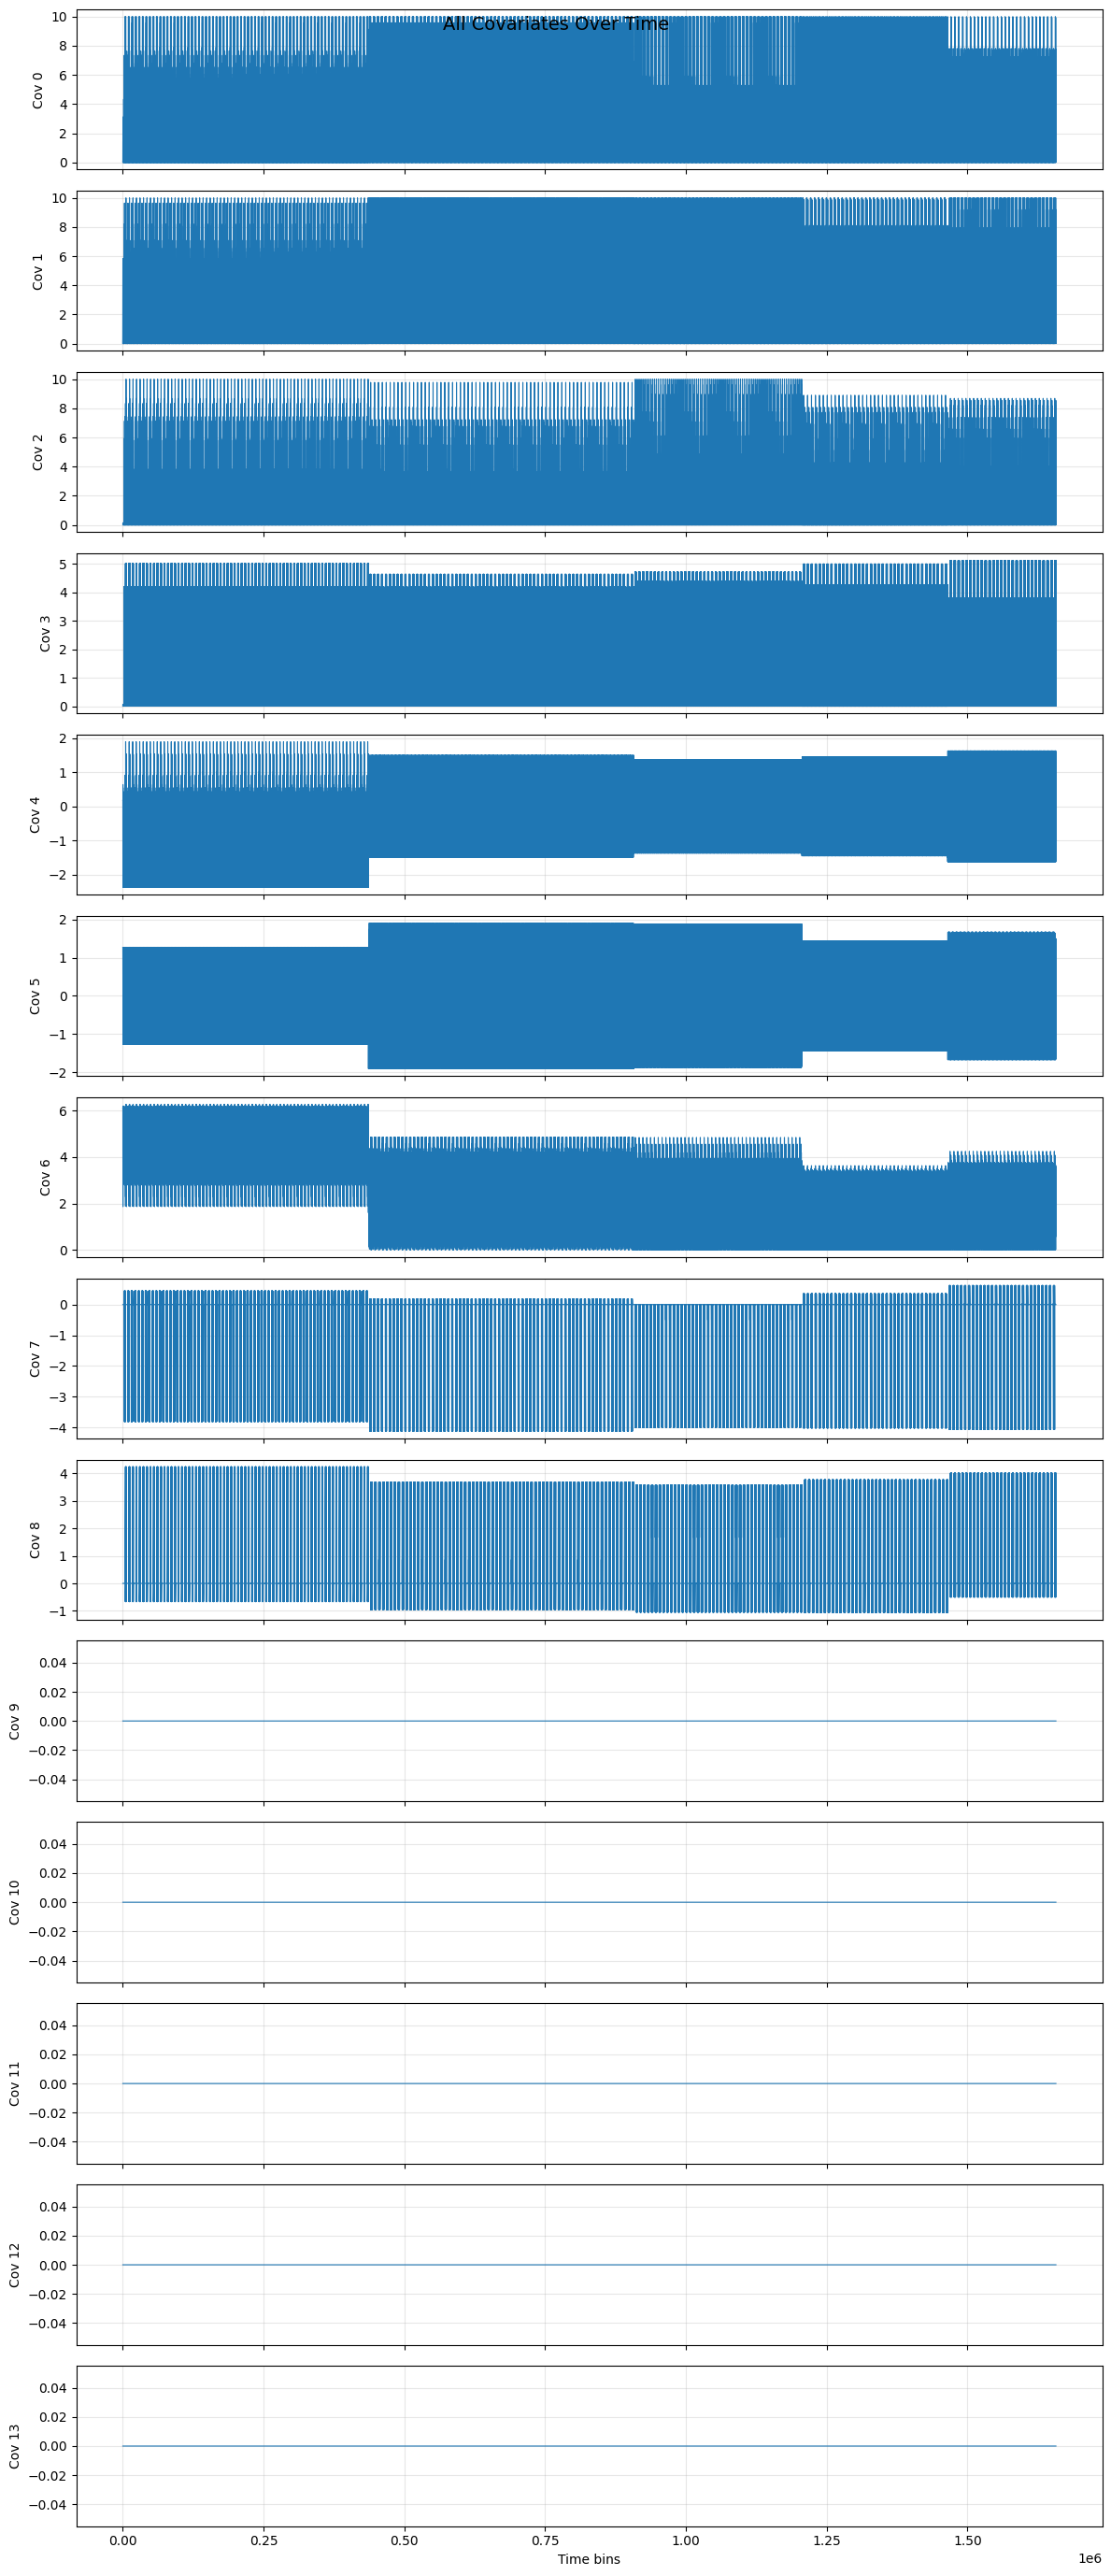

In [23]:
# Plot all covariates across the full recording
def plot_all_covariates(X):
    n_cov = X.shape[0]
    fig, axes = plt.subplots(n_cov, 1, figsize=(12, 2 * n_cov), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X[i], linewidth=0.8)
        axes[i].set_ylabel(f"Cov {i}")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time bins")
    plt.suptitle("All Covariates Over Time", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_all_covariates(X)

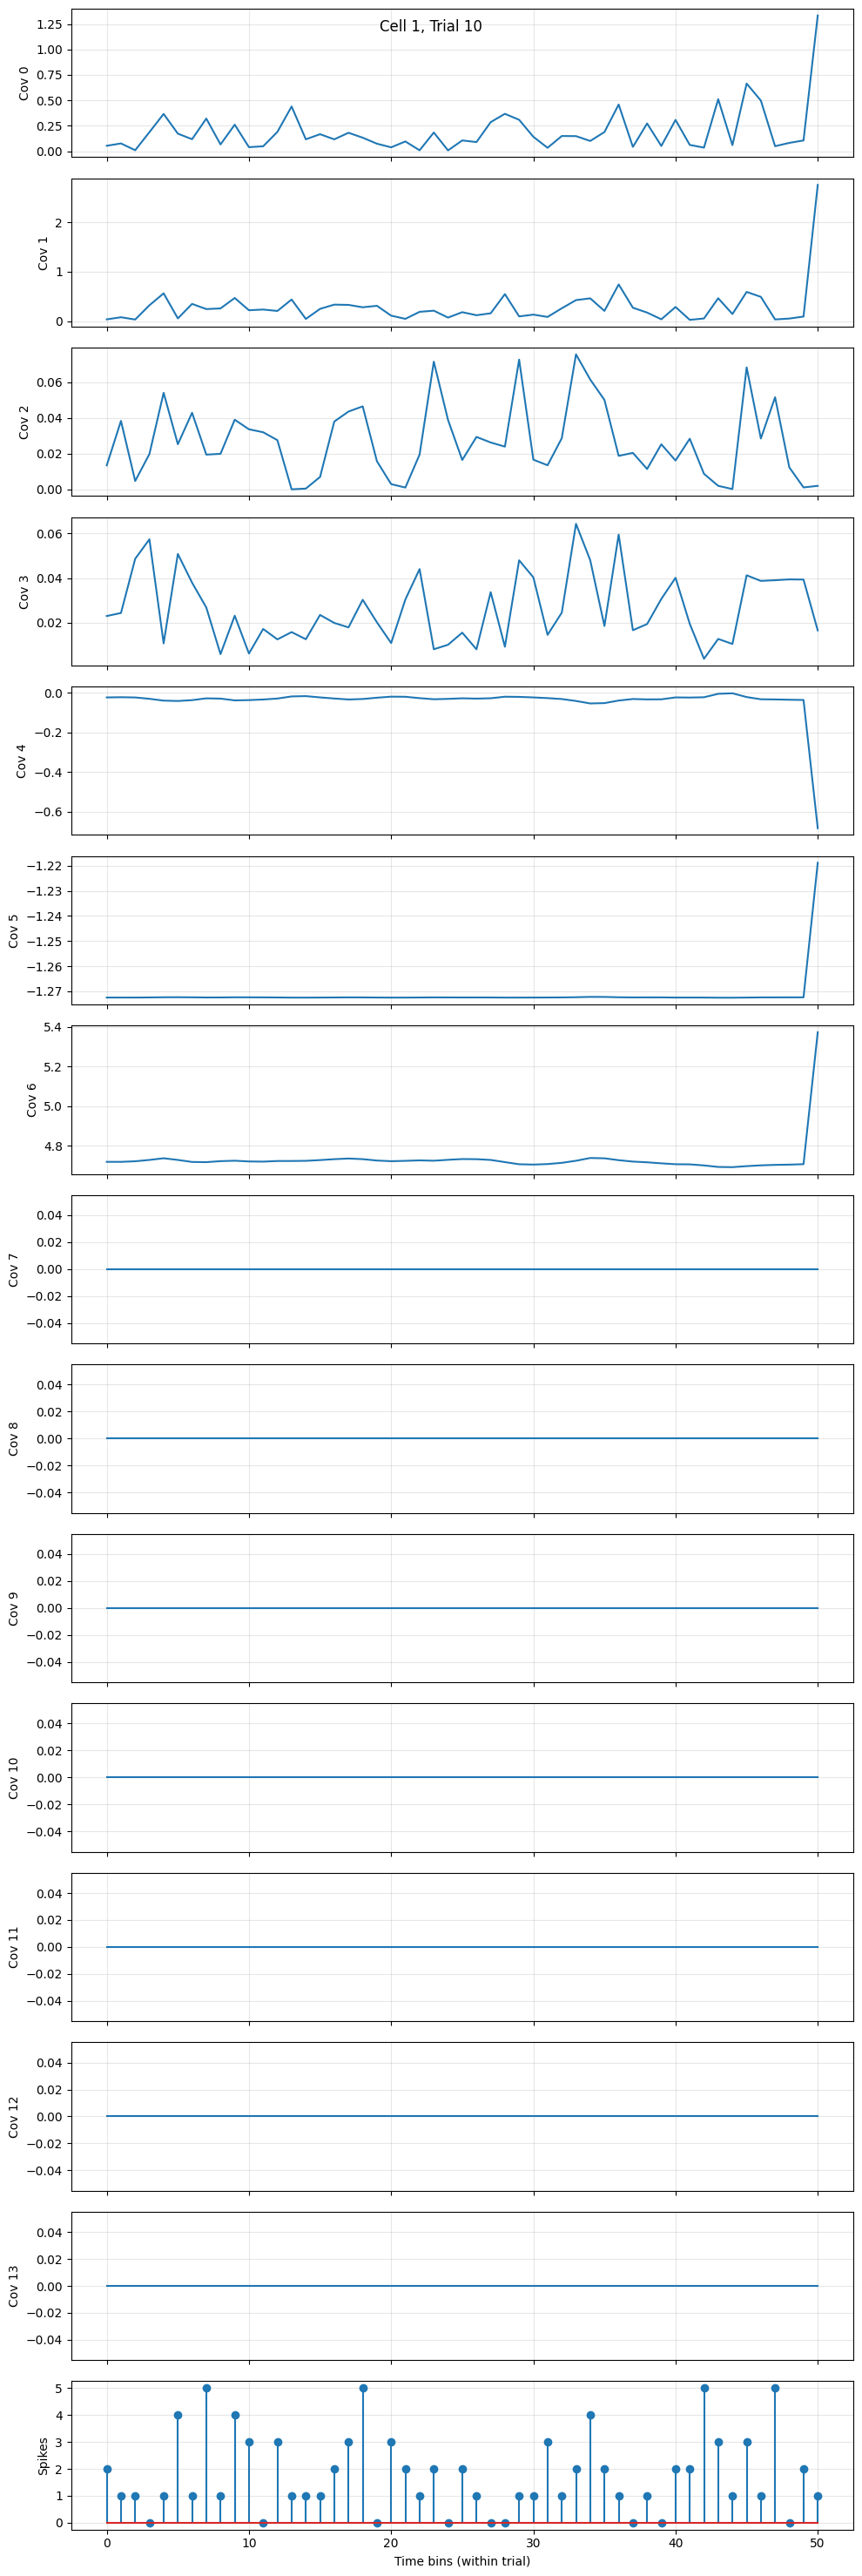

In [24]:
# Plot covariates for a single cell and trial
# Covariate index	Meaning
# 0	Tilt angle
# 1	aPM (angular passive head speed)
# 2	lPM (linear passive head speed)
# 3	aAM (angular active head speed)
# 4	lAM (linear active head speed)
def plot_covariates_and_spikes(X, Y, cell_ids, cell_idx, trial_idx):
    sl = get_trial_slice(cell_idx, trial_idx, cell_ids)
    X_trial = X[:, sl]
    Y_trial = Y[sl]

    # cov_names = ["Tilt angle", "aPM", "lPM", "aAM", "lAM"]
    cov_names = [f"Cov {i}" for i in range(X_trial.shape[0])]

    n_cov = X_trial.shape[0]
    fig, axes = plt.subplots(n_cov + 1, 1, figsize=(10, 2 * (n_cov + 1)), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X_trial[i])
        axes[i].set_ylabel(cov_names[i])
        axes[i].grid(True, alpha=0.3)

    axes[-1].stem(Y_trial)
    axes[-1].set_ylabel("Spikes")
    axes[-1].set_xlabel("Time bins (within trial)")
    axes[-1].grid(True, alpha=0.3)

    plt.suptitle(f"Cell {cell_idx}, Trial {trial_idx}")
    plt.tight_layout()
    plt.show()


# Example call
plot_covariates_and_spikes(X, Y, cell_ids, cell_idx=1, trial_idx=10)

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [ 9 10 11 12 13]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(



Correlation Features (KMeans Clustering) (correlation, kmeans) report:
Cluster 0: cells [1, 9, 11, 12, 13, 14, 15, 19, 21, 24, 25, 30, 36, 46, 47, 52, 54, 58, 60, 64, 67, 68, 70, 73, 78, 88, 90, 92, 99, 100, 106, 112, 114, 124, 126, 129, 130, 136, 138, 139, 140, 141, 142, 143, 144, 153, 154, 159, 162, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 174, 176, 180, 181, 183, 190, 192, 193, 195, 196, 197, 199, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 217, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 239, 242, 243, 244]
Cluster 2: cells [2, 4, 16, 17, 22, 26, 28, 29, 31, 33, 34, 35, 42, 43, 44, 45, 48, 50, 53, 55, 57, 59, 62, 63, 65, 66, 69, 83, 87, 115, 121, 132, 146, 150, 155, 157, 158, 178, 179, 182, 184, 185, 200, 218, 219, 221, 222, 223, 224, 225, 240, 241, 245, 246, 247]
Cluster 3: cells [3, 5, 7, 10, 18, 20, 37, 38, 51, 61, 85, 86, 125, 145, 186, 187, 188, 220, 236, 237, 238]
Cluster 1: cells [6, 8, 23, 27, 32, 39, 40, 41, 49, 56, 71, 72, 74

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.12792782, -0.15553397, -0.08563892, ...,  0.21605519,
          0.07492958, -0.08198872],
        [ 0.24736219,  0.26625799,  0.37307649, ...,  0.02552805,
         -0.21545028,  0.19482316],
        [ 0.08963285,  0.11590652,  0.20026817, ...,  0.11183393,
         -0.05589705,  0.19505772],
        ...,
        [ 0.07702334,  0.07899392,  0.07890581, ..., -0.00760927,
         -0.08490516,  0.06447712],
        [ 0.19941087,  0.13830368,  0.31484744, ..., -0.0028721 ,
         -0.20828207,  0.20243248],
        [ 0.1459949 ,  0.1096393 ,  0.27295101, ...,  0.00772344,
         -0.11335379,  0.11261929]]),
 'scaled_features': array([[-3.22858257, -3.64893108, -2.32109302, ...,  3.16652778,
          2.14710116, -2.54960004],
        [ 2.5789105 ,  2.94522878,  4.43826834, ...,  0.47553135,
         -3.30460271,  2.66811572],
        [ 0.13809933,  0.59468229,  1.89186628, ...,  1.69451152,
         -0.30908858,  2.67253697],
        ...,
        [-0.05702876,  

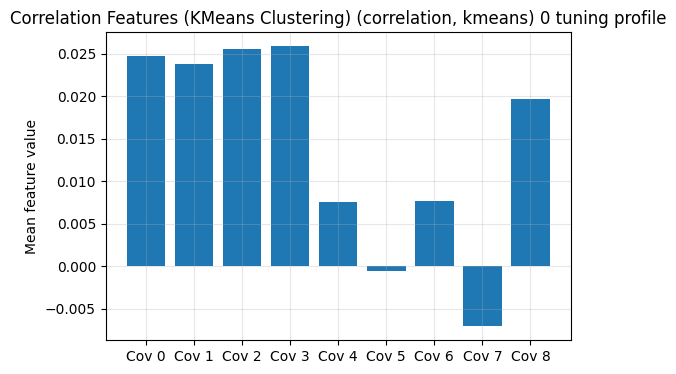

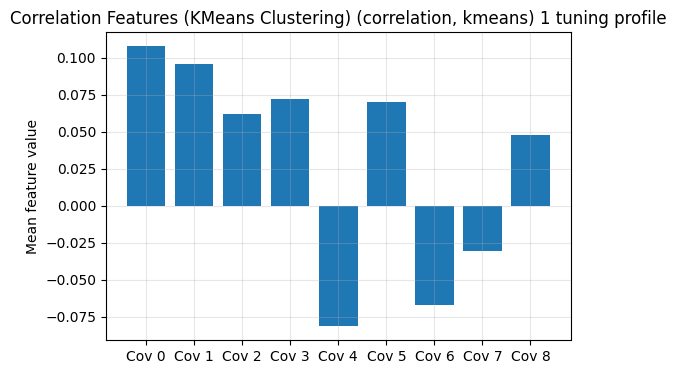

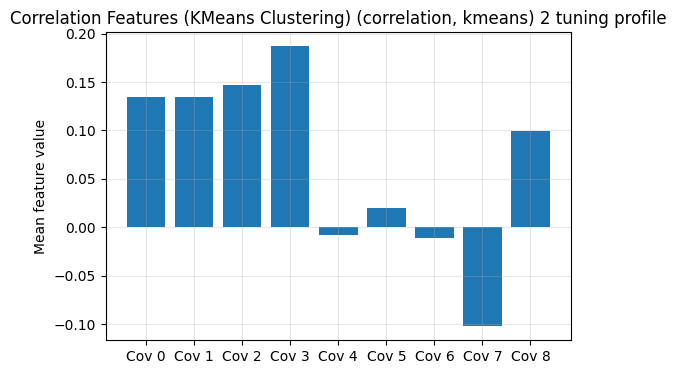

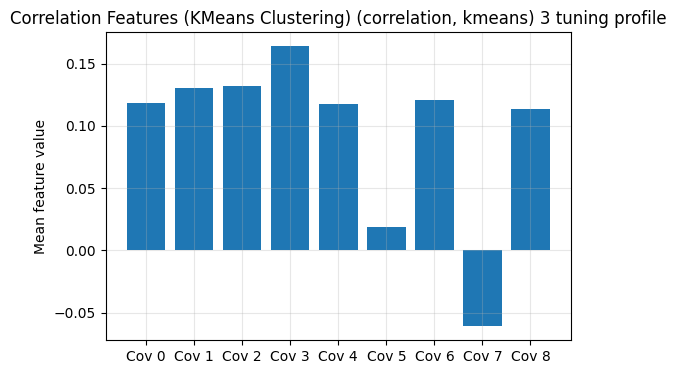

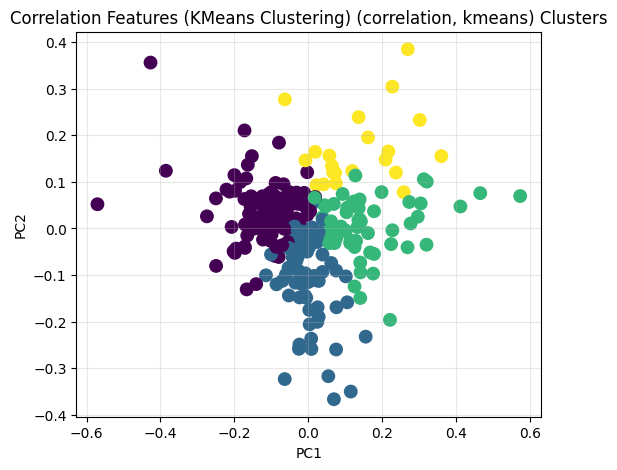

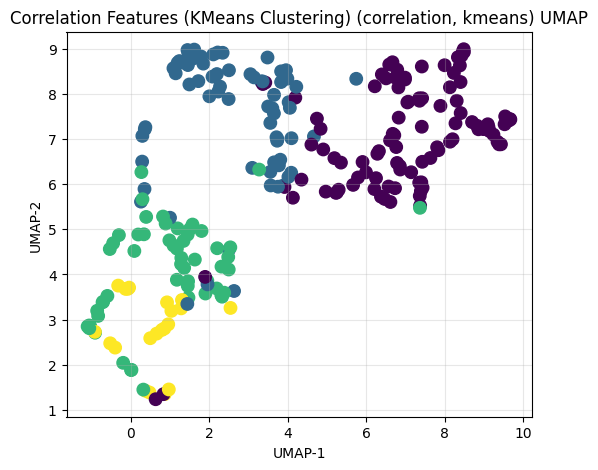

In [25]:
# Correlation features + KMeans
results_corr_km = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="correlation",
    cluster_key="kmeans",
    n_clusters=4,
    title_prefix="Correlation Features (KMeans Clustering)",
)

results_corr_km


GLM Weight Features (KMeans Clustering) (glm, kmeans) report:
Cluster 0: cells [1, 9, 12, 14, 19, 24, 52, 54, 58, 64, 68, 70, 73, 74, 78, 88, 90, 92, 99, 100, 101, 106, 110, 120, 123, 126, 136, 138, 139, 140, 141, 142, 143, 153, 162, 164, 165, 166, 168, 170, 171, 172, 173, 176, 177, 178, 180, 181, 192, 195, 196, 199, 201, 202, 203, 204, 205, 206, 207, 209, 210, 211, 213, 214, 216, 226, 228, 229, 230, 231, 232, 233, 236, 239, 243, 244, 245]
Cluster 1: cells [2, 11, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 34, 36, 37, 38, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 55, 56, 57, 59, 60, 63, 65, 66, 67, 69, 71, 80, 85, 86, 87, 94, 98, 102, 104, 108, 112, 113, 114, 115, 119, 124, 125, 129, 130, 132, 133, 134, 144, 146, 147, 149, 150, 151, 155, 157, 158, 159, 160, 161, 163, 169, 174, 179, 182, 186, 190, 194, 198, 208, 218, 220, 221, 227, 234, 235, 237, 238, 240, 241, 242, 247]
Cluster 2: cells [3, 6, 7, 8, 35, 39, 40, 41, 62, 72, 75, 76, 77, 79, 81, 82, 83, 84, 89,

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.03337407, -0.16278994, -0.01424382, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.03203927,  0.05729988, -0.00394537, ...,  0.        ,
          0.        ,  0.        ],
        [-0.02335462,  0.01332997,  0.06696831, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.01714832,  0.02607564,  0.00712932, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.13122365,  0.0219254 , -0.03928065, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.09262381,  0.02599941, -0.05457065, ...,  0.        ,
          0.        ,  0.        ]]),
 'scaled_features': array([[-1.10509674, -3.95181168, -0.29087329, ...,  0.        ,
          0.        ,  0.        ],
        [-0.1335465 ,  0.38854228, -0.13207128, ...,  0.        ,
          0.        ,  0.        ],
        [-0.95628307, -0.47858096,  0.96141667, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.35471399, -

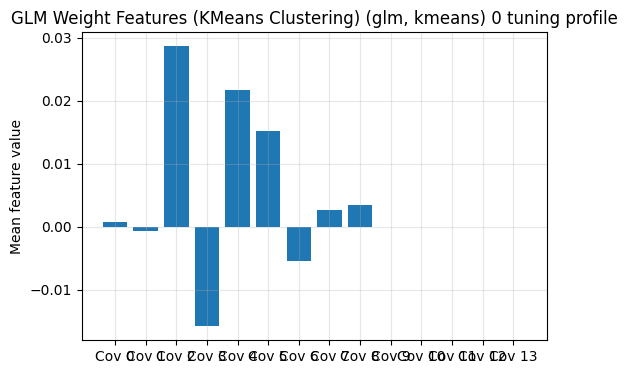

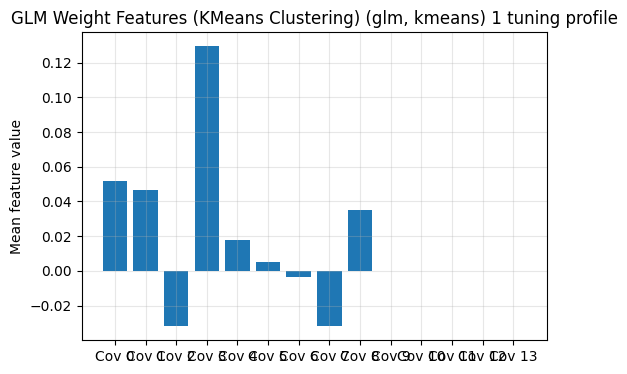

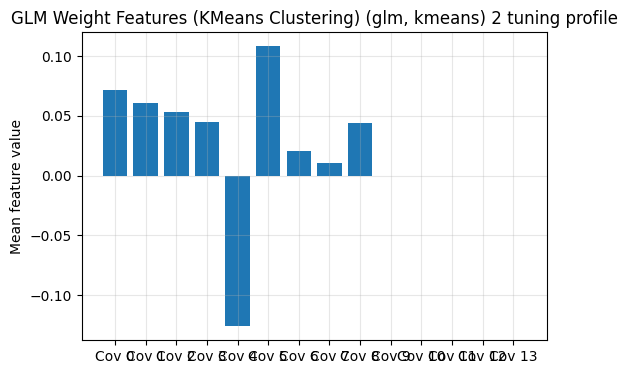

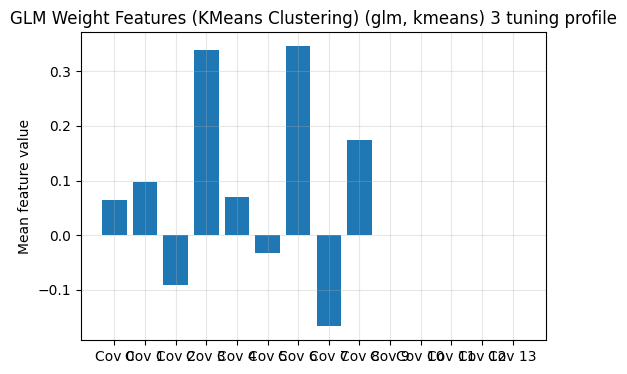

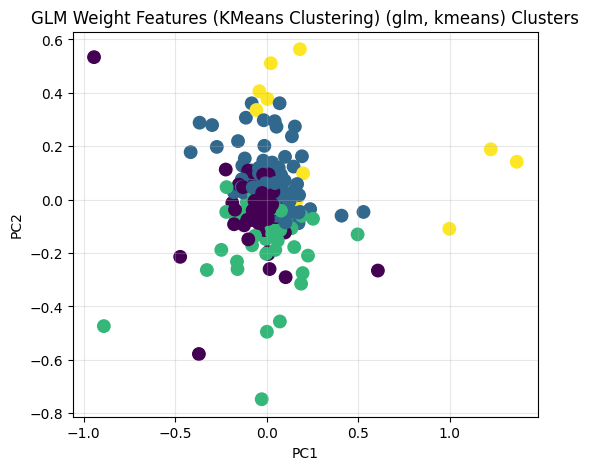

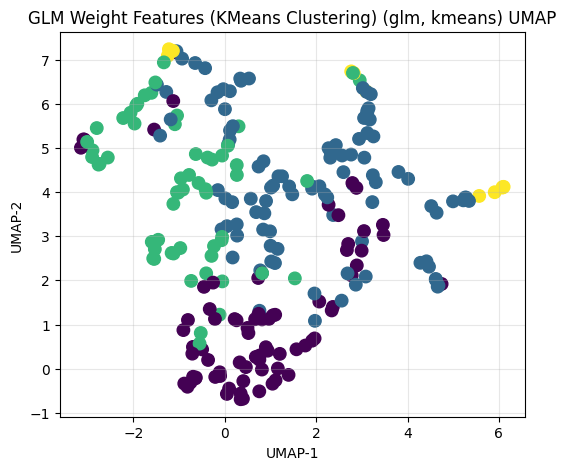

In [26]:
# GLM features + KMeans
results_glm_km = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="glm",
    cluster_key="kmeans",
    n_clusters=4,
    title_prefix="GLM Weight Features (KMeans Clustering)",
)

results_glm_km

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [ 9 10 11 12 13]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Correlation Features (Hierarchical Clustering) (correlation, hierarchical) report:
Cluster 4: cells [1, 58, 126]
Cluster 2: cells [2, 3, 4, 5, 7, 18, 20, 31, 37, 38, 44, 61, 85, 145, 184, 186, 187, 188, 220, 222, 223, 224, 238, 246, 247]
Cluster 5: cells [6, 9, 11, 12, 13, 14, 15, 19, 21, 24, 25, 30, 32, 40, 46, 47, 52, 54, 60, 64, 67, 68, 70, 71, 73, 74, 76, 78, 79, 80, 84, 88, 90, 92, 97, 98, 99, 100, 101, 106, 107, 109, 111, 112, 114, 120, 124, 128, 129, 130, 134, 136, 137, 138, 139, 140, 141, 142, 143, 144, 147, 148, 149, 151, 152, 153, 154, 156, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 176, 177, 180, 181, 183, 190, 191, 192, 193, 196, 197, 198, 199, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 242, 243, 244]
Cluster 3: cells [8, 72, 75, 77, 81, 82, 89, 93, 94, 95, 96, 102, 103, 104, 105, 108, 110, 113, 116, 117, 118, 119, 121, 122, 127, 131, 133, 135, 1

{'features': array([[-0.12792782, -0.15553397, -0.08563892, ...,  0.21605519,
          0.07492958, -0.08198872],
        [ 0.24736219,  0.26625799,  0.37307649, ...,  0.02552805,
         -0.21545028,  0.19482316],
        [ 0.08963285,  0.11590652,  0.20026817, ...,  0.11183393,
         -0.05589705,  0.19505772],
        ...,
        [ 0.07702334,  0.07899392,  0.07890581, ..., -0.00760927,
         -0.08490516,  0.06447712],
        [ 0.19941087,  0.13830368,  0.31484744, ..., -0.0028721 ,
         -0.20828207,  0.20243248],
        [ 0.1459949 ,  0.1096393 ,  0.27295101, ...,  0.00772344,
         -0.11335379,  0.11261929]]),
 'scaled_features': array([[-3.22858257, -3.64893108, -2.32109302, ...,  3.16652778,
          2.14710116, -2.54960004],
        [ 2.5789105 ,  2.94522878,  4.43826834, ...,  0.47553135,
         -3.30460271,  2.66811572],
        [ 0.13809933,  0.59468229,  1.89186628, ...,  1.69451152,
         -0.30908858,  2.67253697],
        ...,
        [-0.05702876,  

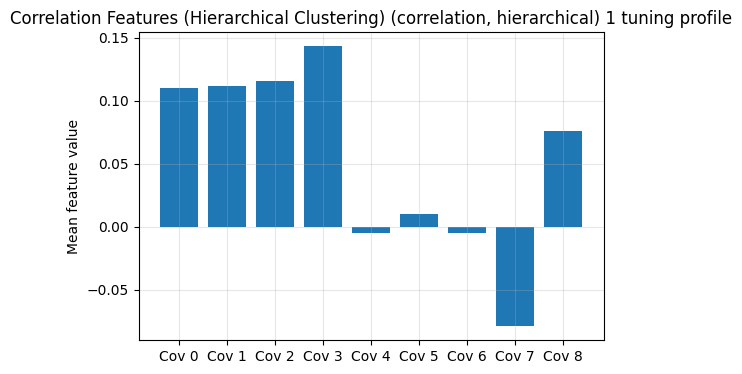

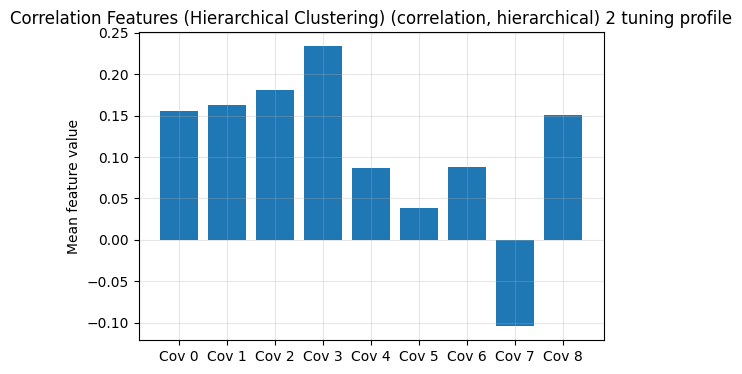

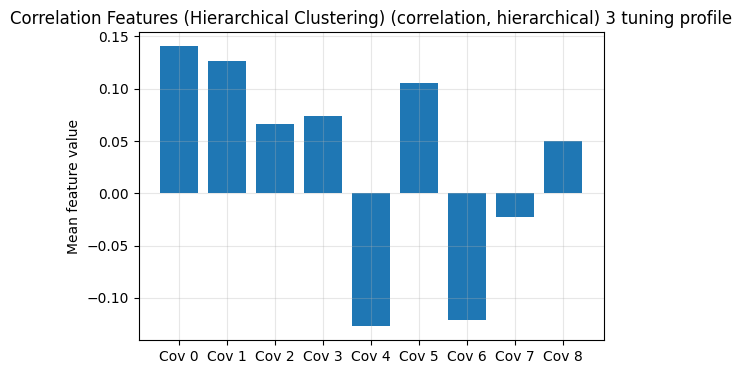

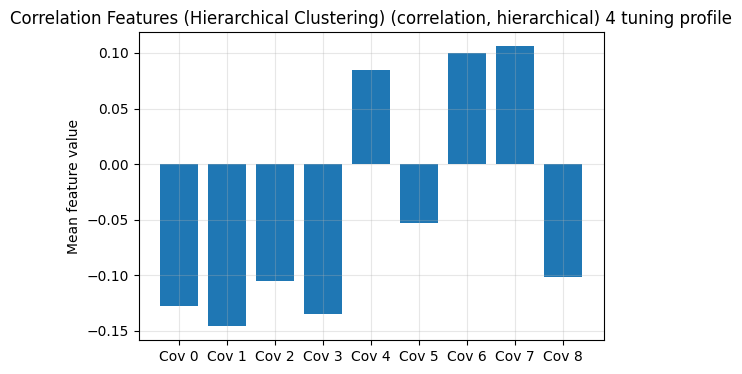

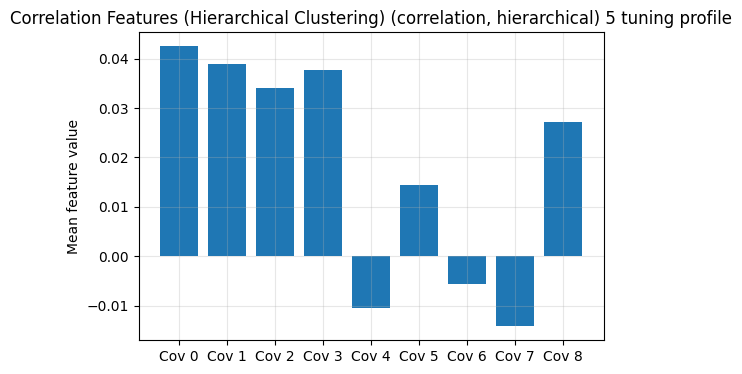

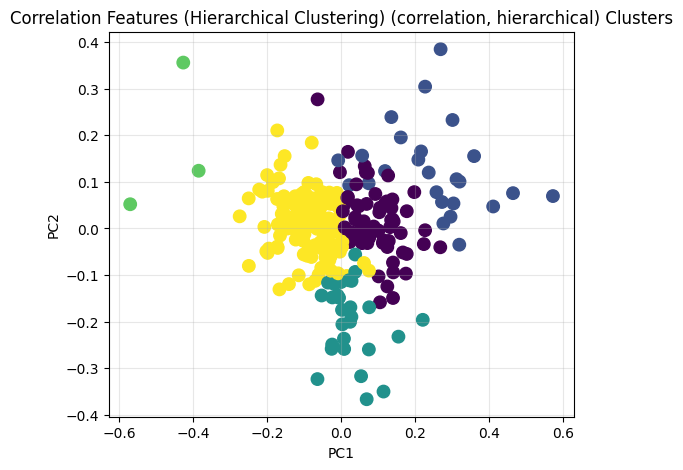

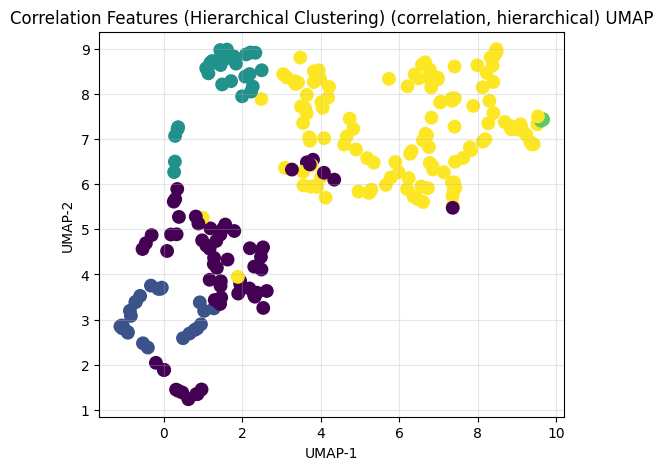

In [27]:
# Correlation features + Hierarchical Clustering
results_corr_hier = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="correlation",
    cluster_key="hierarchical",
    n_clusters=5,
    title_prefix="Correlation Features (Hierarchical Clustering)",
)

results_corr_hier


GLM Weight Features (Hierarchical Clustering) (glm, hierarchical) report:
Cluster 3: cells [1, 2, 3, 4, 5, 7, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 94, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 128, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 226

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.03337407, -0.16278994, -0.01424382, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.03203927,  0.05729988, -0.00394537, ...,  0.        ,
          0.        ,  0.        ],
        [-0.02335462,  0.01332997,  0.06696831, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.01714832,  0.02607564,  0.00712932, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.13122365,  0.0219254 , -0.03928065, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.09262381,  0.02599941, -0.05457065, ...,  0.        ,
          0.        ,  0.        ]]),
 'scaled_features': array([[-1.10509674, -3.95181168, -0.29087329, ...,  0.        ,
          0.        ,  0.        ],
        [-0.1335465 ,  0.38854228, -0.13207128, ...,  0.        ,
          0.        ,  0.        ],
        [-0.95628307, -0.47858096,  0.96141667, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.35471399, -

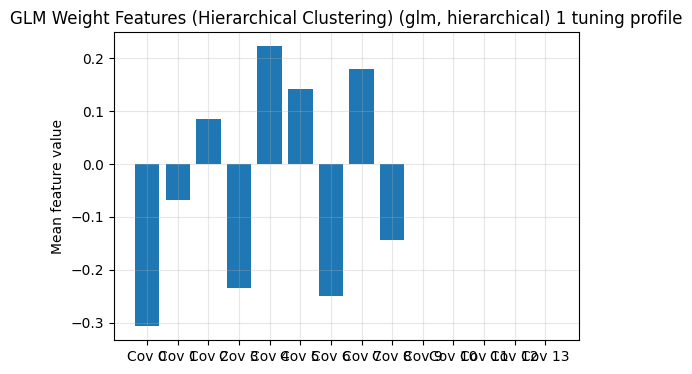

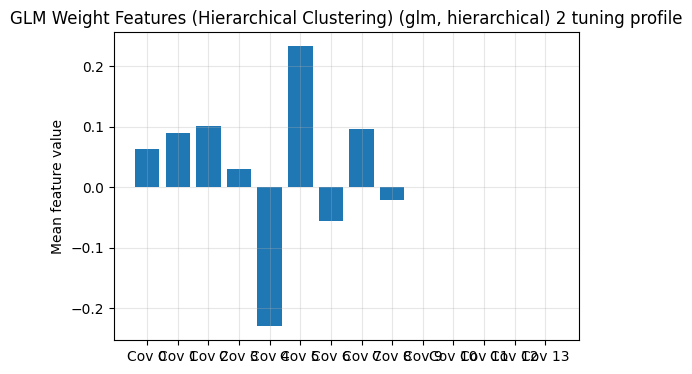

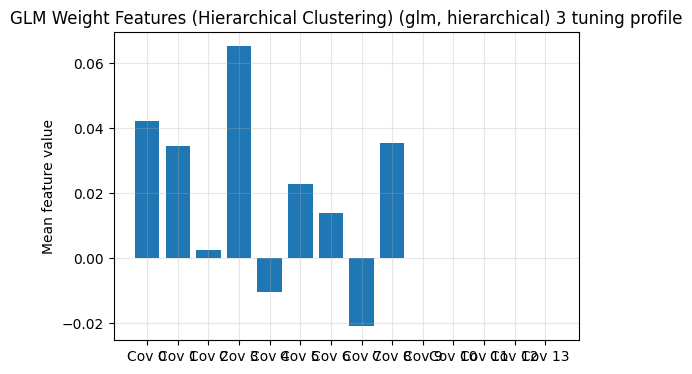

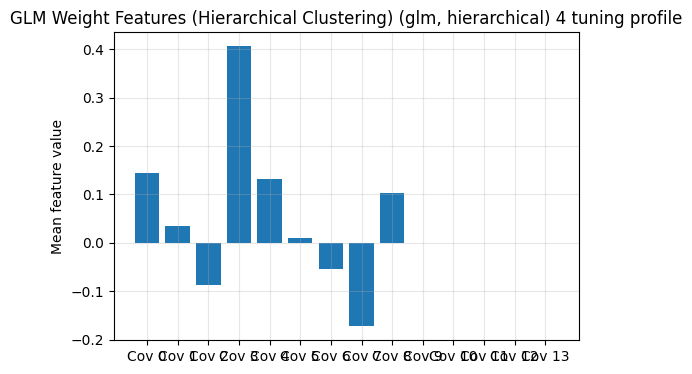

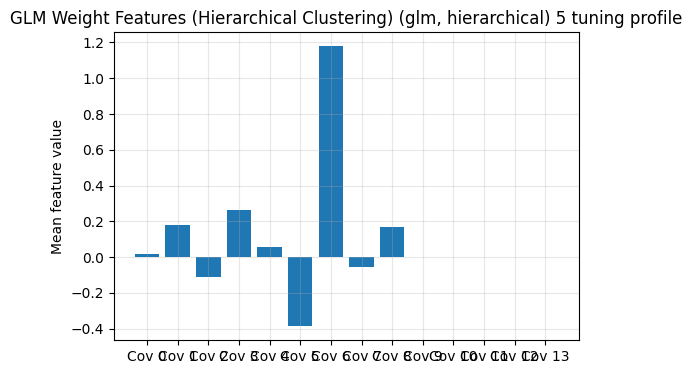

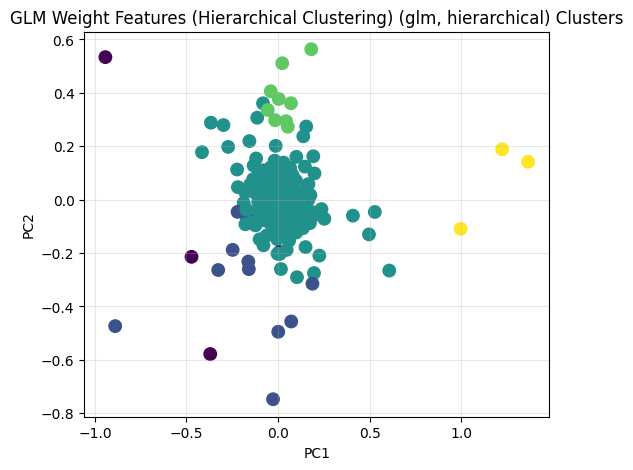

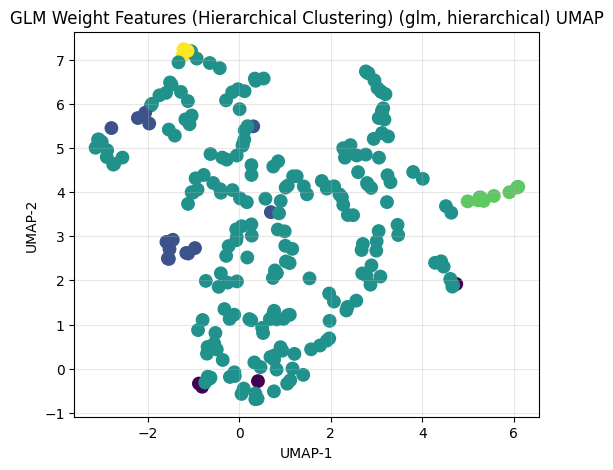

In [28]:
# GLM features + Hierarchical Clustering
results_glm_hier = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="glm",
    cluster_key="hierarchical",
    n_clusters=5,
    title_prefix="GLM Weight Features (Hierarchical Clustering)",
)

results_glm_hier